# Dog Bark Spectrogram
Uses Librosa and SciPy to process and visualize bark audio.

In [1]:
import librosa
import matplotlib.pyplot as plt
import scipy.signal as scipysig
import numpy as np

In [2]:
# Setting parameters
n_fft = 1024
nf = 160
filter_val = 500

In [3]:
# Convert to dB
def log_transform(spec, scale=10**(-5)):
    return 20 * np.log10(spec + scale * np.ones(spec.shape))

# Load audio
def load_data(uploaded_file):
    # Read in file
    (s, framerate) = librosa.core.load(uploaded_file, sr=None, mono=False)

    # Normalize
    s = s/np.max(s)**2

    return s, framerate

In [4]:
def spectrogram(vid, s, framerate, start=None, end=None):
    # Convert times to samples
    if end is not None:
        end = int(np.ceil(end * framerate))
    if start is not None:
        start = int(np.trunc(start * framerate))
        s = s[start:end]

    s = np.asarray(s).squeeze()
    
    if s.ndim == 2:
        s = s.mean(axis=0)

    # STFT
    freqs, times, spec = scipysig.stft(s, fs=framerate, nperseg=n_fft)
    spec = np.abs(spec)

    # Power / intensity
    power = np.abs(spec) ** 2

    # Log spectrogram (more stable visually + for ML)
    log_spec = np.log(power + 1e-8)

    return freqs, times, power, log_spec

def plot_spectrogram(freqs, times, spec):
    plt.figure(figsize=(10, 4))
    plt.pcolormesh(times, freqs, spec, shading='gouraud')
    plt.ylim(0, 14000)
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.title('Log Spectrogram')
    plt.colorbar(label='Log Power')
    plt.tight_layout()
    plt.show()

/var/folders/hh/y6rb3zr97wl5p6zrvdgbhvtw0000gp/T/ipykernel_3501/1648082373.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  (s, framerate) = librosa.core.load(uploaded_file, sr=None, mono=False)
/Applications/anaconda3/envs/chihuahua/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


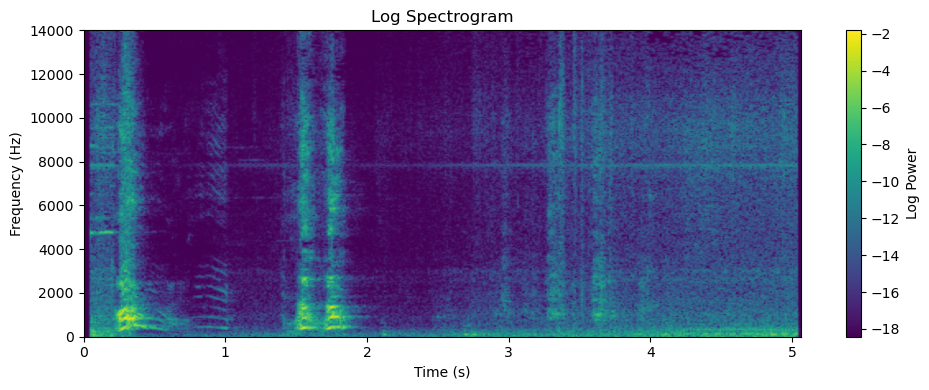

In [5]:
# Load dog video
vid = 'files/dogs1.mp4'
s, framerate = load_data(vid)

freqs, times, power, log_spec = spectrogram(vid, s, framerate)
plot_spectrogram(freqs, times, log_spec)